### Configuração do LDA

In [21]:
import pandas as pd
import gensim
from gensim import corpora
from gensim.models import LdaSeqModel
import nltk
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# Carrega o dataset
df_novo = pd.read_csv('./datasets/database-lemmetizado.csv.zip', compression='zip')
df_novo = df_novo.sort_values('date_published').reset_index(drop=True)

In [23]:
documents = df_novo['tokens'].dropna().astype(str).tolist()
df_novo[df_novo['patent_count'] > 0].head()

,lens_id,jurisdiction,doc_number,kind,date_published,doc_key,docdb_id,lang,biblio,families,...,inventors_detailed,inventor_names,invention_title_text,patent_count,patent_lens_ids,patent_status,application_expiry_date,picked,title_abstract,tokens
73,050-366-554-331-419,BR,7702039,U,1999-10-13,BR_7702039_U_19991013,383303056,NaN,{'publication_reference': {'jurisdiction': 'BR...,{'simple_family': {'members': [{'document_id':...,...,"[{'residence': None, 'name': 'DREHER ROBERTO E...",['DREHER ROBERTO EDUARDO'],Disposição construtiva introduzida em reservat...,1,['067-459-945-424-014'],DISCONTINUED,2004-06-22,E03,Disposição construtiva introduzida em reservat...,"['disposição', 'construtivo', 'introduzer', 'r..."
89,103-537-706-775-962,BR,9805611,A,1999-11-09,BR_9805611_A_19991109,295401940,NaN,{'publication_reference': {'jurisdiction': 'BR...,{'simple_family': {'members': [{'document_id':...,...,"[{'residence': None, 'name': 'BROWN JEFFREY DA...","['BROWN JEFFREY DAVID', 'MCKELVEY JAMES LOUIS'...","Estrutura de parede laminada, isolamento exter...",1,['069-627-757-858-192'],DISCONTINUED,2020-09-24,E04,"Estrutura de parede laminada, isolamento exter...","['estrutura', 'parede', 'laminar', 'isolamento..."
134,164-464-275-060-487,BR,7800045,U,1999-12-07,BR_7800045_U_19991207,383304521,NaN,{'publication_reference': {'jurisdiction': 'BR...,{'simple_family': {'members': [{'document_id':...,...,"[{'residence': None, 'name': 'ABREU JOAO ALEXA...",['ABREU JOAO ALEXANDRE DE'],disposições construtivas introduzidas em torre...,3,"['008-579-359-025-113', '196-924-085-516-274',...",EXPIRED,NaN,E04,disposições construtivas introduzidas em torre...,"['disposição', 'construtivo', 'introduzir', 't..."
174,105-894-667-094-483,BR,9609213,A,1999-12-14,BR_9609213_A_19991214,297761449,NaN,{'publication_reference': {'jurisdiction': 'BR...,{'simple_family': {'members': [{'document_id':...,...,"[{'residence': None, 'name': 'BRYANT STANLEY'}]",['BRYANT STANLEY'],"Processo de construção de coluna (s), parede (...",1,['066-890-591-705-207'],EXPIRED,NaN,E04,"Processo de construção de coluna (s), parede (...","['processo', 'construção', 'coluna', 'parede',..."
181,072-433-898-185-211,BR,9712576,A,1999-12-21,BR_9712576_A_19991221,296632552,NaN,{'publication_reference': {'jurisdiction': 'BR...,{'simple_family': {'members': [{'document_id':...,...,"[{'residence': None, 'name': 'COUTTS ERNEST'}]",['COUTTS ERNEST'],Capa de estaca.,3,"['119-051-042-479-896', '132-953-997-767-974',...",DISCONTINUED,2004-06-08,E02,"Capa de estaca. ""CAPA DE ESTACA"". Uma capa de ...","['capa', 'estaca', 'capa', 'estaca', 'capa', '..."


In [24]:

# 1. Converter a coluna de datas para datetime
df_novo['date_published'] = pd.to_datetime(df_novo['date_published'], errors='coerce')

# 2. Definir as faixas de 4 anos
year_slice = 2

start_year = df_novo['date_published'].dt.year.min()
end_year = df_novo['date_published'].dt.year.max()
bins = list(range(start_year, end_year + year_slice + 1, year_slice))
period_labels = [f"{y}-{y+year_slice-1}" for y in bins[:-1]]

print(period_labels)

# 3. Criar coluna de faixa temporal
df_novo['period'] = pd.cut(df_novo['date_published'].dt.year, bins=bins, labels=period_labels, right=False)

['1999-2000', '2001-2002', '2003-2004', '2005-2006', '2007-2008', '2009-2010', '2011-2012', '2013-2014', '2015-2016', '2017-2018', '2019-2020', '2021-2022', '2023-2024']


In [25]:
documents = df_novo['tokens'].dropna().astype(str).tolist()

In [26]:
# Usar esse caso o dataset esteja pre-processado
def tokenize_text(text):
    """
    Função para tokenizar o texto.
    """

    # Converte para minúsculas e separa em palavras
    tokens = text.lower().split()

    return tokens

# Tokeniza os textos
processed_docs = [tokenize_text(doc) for doc in documents]

# Cria dicionário e corpus
# O dicionário mapeia cada palavra a um ID único.
dictionary = corpora.Dictionary(processed_docs)

# O corpus é a representação Bag-of-Words de cada documento.
# Para cada documento, ele contém uma lista de tuplas (ID_da_palavra, frequência).
corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

In [27]:
print(f"Número de documentos: {len(corpus)}")
print(f"Tamanho do dicionário: {len(dictionary)}")
print(f"Exemplo de documento (Bag-of-Words): {corpus[0]}")
print(f"processed_docs[0]: {processed_docs[0]}")

Número de documentos: 25240
Tamanho do dicionário: 47851
Exemplo de documento (Bag-of-Words): [(0, 1), (1, 1), (2, 1), (3, 4), (4, 2), (5, 2), (6, 1), (7, 4), (8, 1), (9, 3), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 3), (19, 1), (20, 1), (21, 1), (22, 1), (23, 1), (24, 1), (25, 1), (26, 1), (27, 1), (28, 1), (29, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 4), (35, 1), (36, 1)]
processed_docs[0]: ["['dispositivo',", "'eletrocrèmico',", "'combinação',", "'eletrocrèmica',", "'patente',", "'invenção',", "'dispositivo',", "'eletrocrèmico',", "'combinação',", "'eletrocrèmico',", "'apresentar',", "'dispositivo',", "'eletrocrómico',", "'aplicação',", "'superfície',", "'dispositivo',", "'utilizar',", "'camada',", "'regulação',", "'óptico',", "'modo',", "'reduzir',", "'pequeno',", "'interferência',", "'óptico',", "'camada',", "'estrutura',", "'modo',", "'aumentar',", "'transparência',", "'óptico',", "'uniforme',", "'sintonização',", "'óptico',", "'permitir',

### Treinamento do modelo

In [28]:
train = False

# 4. Treinar o modelo DTM (LdaSeqModel)

if train:
	ldaseq = LdaSeqModel(
		corpus=corpus,
		time_slice=df_novo['period'].value_counts().sort_index().to_list(),
		id2word=dictionary,
		initialize='gensim',
		num_topics=10
	)

print("Modelo DTM treinado com sucesso!")

Modelo DTM treinado com sucesso!


In [29]:
if train:
    ldaseq.save("./modelos/dtm_model")

In [30]:
ldaseq = LdaSeqModel.load("./modelos/dtm_model")

In [31]:
# Exibe os tópicos encontrados
for idx, topic in enumerate(ldaseq.print_topics()):

    print(f'Tópico {idx}: {topic}')

    

Tópico 0: [("'controle',", 0.01958593855247271), ("'dispositivo',", 0.01858886484058117), ("'máquina',", 0.017207919523405606), ("'aparelho',", 0.015880097589856708), ("'unidade',", 0.015186808778435467), ("'método',", 0.01393861783611014), ("'elétrico',", 0.013104067889537068), ("'energia',", 0.01027336872693694), ("'hidráulico',", 0.00970418513116426), ("'invenção',", 0.008477926835199653), ("'motor',", 0.008385478627256599), ("'incluir',", 0.007988031018922651), ("'operação',", 0.007675671659080033), ("'compreender',", 0.007200106575378134), ("'sinal',", 0.007150263261426815), ("'veículo',", 0.007016250652221077), ("'controlar',", 0.006639953617837922), ("'fluido',", 0.006625620938433615), ("'bomba',", 0.00639576655908076), ("'pressão',", 0.005495177032935086)]
Tópico 1: [("'janela',", 0.06656030843853318), ("'porta',", 0.059965304683575624), ("'perfil',", 0.038620447356811034), ("'vidro',", 0.037302701356675745), ("'folha',", 0.024960444786682814), ("'b',", 0.024764736173758805), (

### Gráfico de Tópicos

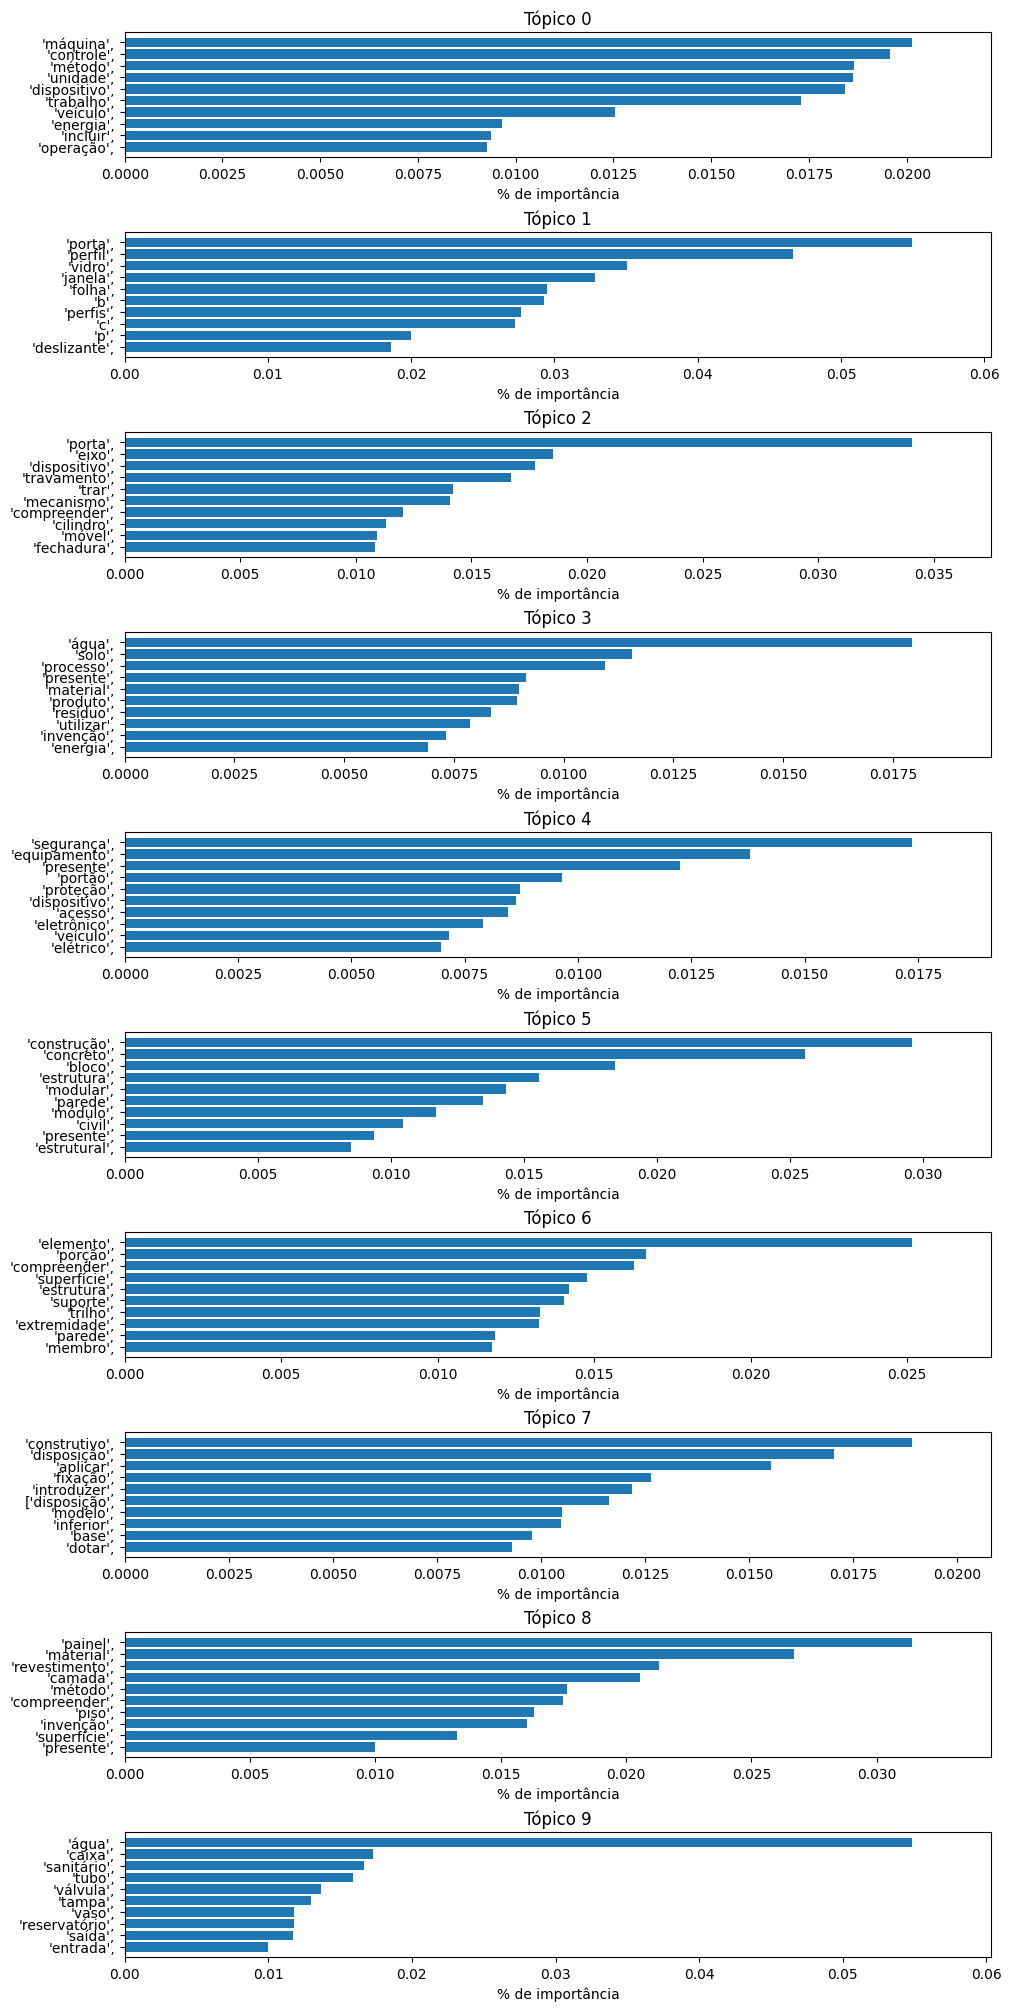

In [32]:
# Extrai os tópicos e palavras (no primeiro time slice)
topics = ldaseq.print_topics(top_terms=10, time=6)

fig, axes = plt.subplots(len(topics), 1, figsize=(10, 2 * len(topics)), constrained_layout=True)

for topic_idx, terms in enumerate(topics):
    words = [w for w, p in terms]
    probs = [p for w, p in terms]
    axes[topic_idx].barh(words, probs)
    axes[topic_idx].set_title(f'Tópico {topic_idx}')
    axes[topic_idx].invert_yaxis()
    axes[topic_idx].set_xlabel('% de importância')
    axes[topic_idx].set_xlim(0, max(probs)*1.1)

fig.savefig('./graficos/lda_topicos.png', dpi=300)
plt.show()
plt.close(fig)

### Data Frame com os tópicos de cada patente

In [33]:
# 1. Definir os nomes dos tópicos conforme sua interpretação.
topic_names = {
    0: 'Controle de máquinas e sistemas de energia',
    1: 'Esquadrias e sistemas de vedação',
    2: 'Fechaduras e mecanismos de travamento',
    3: 'Água, solo e tratamento ambiental',
    4: 'Segurança e acesso',
    5: 'Construção civil e elementos estruturais',
    6: 'Componentes estruturais e de fixação',
    7: 'Soluções construtivas e montagem mecânica',
    8: 'Materiais de revestimento e isolamento',
    9: 'Sistemas hidráulicos sanitários'
}

In [34]:
# 2. Preparar uma lista para armazenar os dados de cada patente.
corpus_topics_data = []

# 3. Iterar sobre cada documento no seu corpus.
for i, doc_bow in enumerate(corpus):
    # Pega a distribuição de tópicos para o documento atual.
    forward_citations_count = df_novo["patent_count"].iloc[i]

    doc_topics = ldaseq.doc_topics(i)
        
    # Adiciona o ID e titulo da patente à informação.
    # Assumindo que 'lista_patentes' tem os títulos ou IDs.
    topic_probabilities = {}
    for topic_num, prob_topic in enumerate(doc_topics):
        topic_probabilities[topic_names[topic_num]] = prob_topic
    topic_probabilities['ID'] = df_novo["lens_id"].iloc[i]
    topic_probabilities['Nome'] = df_novo["invention_title_text"].iloc[i]
    topic_probabilities['Forward Citations Count'] = forward_citations_count
    topic_probabilities['Backward Citations'] = df_novo["patent_lens_ids"].iloc[i]
    topic_probabilities['Período'] = df_novo["period"].iloc[i]
    
    # Adiciona o dicionário completo à nossa lista de dados.
    corpus_topics_data.append(topic_probabilities)

# 4. Criar o DataFrame do pandas.
df_topics = pd.DataFrame(corpus_topics_data)

# 5. Criar uma coluna para identificar o tópico dominante de cada patente.
# O método idxmax() encontra o nome da coluna (nosso nome de tópico) com o maior valor na linha.
df_topics['Tópico Principal'] = df_topics[list(topic_names.values())].idxmax(axis=1)

# 6. Ordena os campos para melhor visualização.
df_topics = df_topics[['ID', 'Nome', 'Tópico Principal', 'Forward Citations Count', 'Período'] + list(topic_names.values())]

In [35]:
df_topics

,ID,Nome,Tópico Principal,Forward Citations Count,Período,Controle de máquinas e sistemas de energia,Esquadrias e sistemas de vedação,Fechaduras e mecanismos de travamento,"Água, solo e tratamento ambiental",Segurança e acesso,Construção civil e elementos estruturais,Componentes estruturais e de fixação,Soluções construtivas e montagem mecânica,Materiais de revestimento e isolamento,Sistemas hidráulicos sanitários
0,171-098-512-075-612,Dispositivo eletrocrÈmico e combinação eletroc...,Materiais de revestimento e isolamento,0,1999-2000,0.094605,0.035604,0.000192,0.000192,0.244241,0.081302,0.000192,0.000192,0.543288,0.000192
1,046-440-553-666-653,Estore celular.,Materiais de revestimento e isolamento,0,1999-2000,0.000178,0.000178,0.000178,0.000178,0.000178,0.026220,0.170465,0.000178,0.802068,0.000178
2,157-865-805-179-279,Aparelho para cooperar com uma máquina; tal co...,Controle de máquinas e sistemas de energia,0,1999-2000,0.475998,0.000116,0.318843,0.000116,0.000116,0.000116,0.204346,0.000116,0.000116,0.000116
3,104-140-108-095-175,Dispositivo de travamento para portas de gabin...,Fechaduras e mecanismos de travamento,0,1999-2000,0.000126,0.039095,0.762810,0.000126,0.000126,0.097809,0.000126,0.099527,0.000126,0.000126
4,023-683-667-869-67X,Composições com enchimento altamente inorgnico,Materiais de revestimento e isolamento,0,1999-2000,0.000103,0.000103,0.000103,0.057156,0.000103,0.056974,0.000103,0.000103,0.814098,0.071154
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25235,114-648-369-763-290,Disposição construtiva aplicada em cabeça auto...,Soluções construtivas e montagem mecânica,0,2023-2024,0.000082,0.000082,0.171411,0.000082,0.000082,0.221817,0.000082,0.606198,0.000082,0.000082
25236,154-085-879-471-233,Disposição construtiva proporcionada em mureta...,Construção civil e elementos estruturais,0,2023-2024,0.000175,0.000175,0.000175,0.000175,0.000175,0.433360,0.000175,0.180804,0.000175,0.384609
25237,052-411-343-097-485,Aperfeiçoamento introduzido em barraca de teto...,Soluções construtivas e montagem mecânica,0,2023-2024,0.000093,0.021942,0.240371,0.043162,0.000093,0.000093,0.181501,0.501200,0.000093,0.011453
25238,056-089-956-710-61X,Cancela para impedir o acesso a lugar de estac...,Segurança e acesso,0,2023-2024,0.000147,0.000147,0.000147,0.041264,0.867268,0.000147,0.000147,0.000147,0.090440,0.000147


### Cálculo da Emergência dos Tópicos

In [36]:
# multiply every topic column by Forward Citations
weighted = df_topics[topic_names.values()].mul(df_topics["Forward Citations Count"], axis=0)

# group by period and sum
topic_emergence_scores = (
    weighted.groupby(df_topics["Período"])
            .sum()
            .reindex(period_labels)  # keep desired order/index
)

topic_emergence_scores

,Controle de máquinas e sistemas de energia,Esquadrias e sistemas de vedação,Fechaduras e mecanismos de travamento,"Água, solo e tratamento ambiental",Segurança e acesso,Construção civil e elementos estruturais,Componentes estruturais e de fixação,Soluções construtivas e montagem mecânica,Materiais de revestimento e isolamento,Sistemas hidráulicos sanitários
Período,,,,,,,,,,
1999-2000,1.742822,1.019271,1.458951,1.880729,4.459561,6.507176,5.065908,6.236265,2.683847,4.945468
2001-2002,1.511976,0.638971,2.173279,3.420377,3.170915,3.961041,4.986946,4.519159,1.195132,5.422203
2003-2004,2.858754,1.534019,3.731745,4.052406,4.320355,6.603870,3.969374,8.311370,3.640707,5.977399
2005-2006,4.809939,2.312632,3.931595,9.565762,8.327807,16.744986,7.594924,20.307495,6.799226,8.605636
2007-2008,8.391855,4.092366,7.775127,5.801553,13.586268,20.371322,10.355437,21.045303,5.764490,18.816281
2009-2010,8.562896,5.522610,13.479118,16.179800,19.601363,35.245298,10.513019,38.213506,4.873647,17.808742
2011-2012,8.981983,4.321452,7.280602,11.560472,12.663733,16.915821,12.281883,21.594114,12.457385,13.942554
2013-2014,9.442700,12.067661,12.619402,19.153661,34.012607,34.166644,13.845074,39.872270,4.772165,22.047816
2015-2016,12.164177,10.635730,19.835462,15.285151,60.268398,31.446688,29.187092,75.854217,18.737999,15.585085


## Visualizar uma patente especifica

C:\Users\pedro\AppData\Local\Temp\ipykernel_3980\336728410.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=probabilidades_topicos.index, y=probabilidades_topicos.values, palette='viridis')


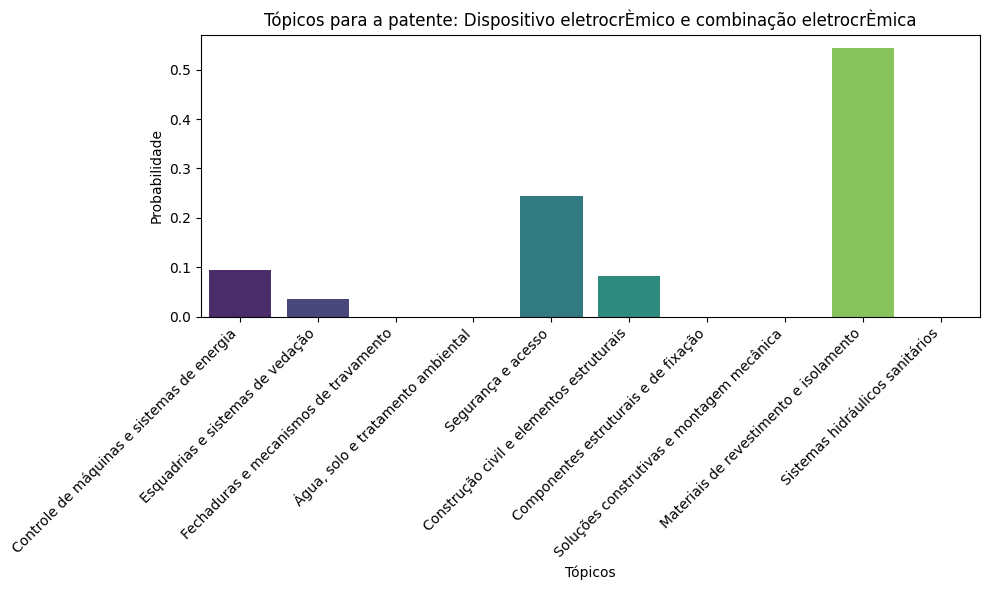

In [37]:
indice_patente = 0
patente_especifica = df_topics.iloc[indice_patente]

# Pega apenas as colunas que representam as probabilidades dos tópicos
probabilidades_topicos = patente_especifica[list(topic_names.values())]

# Cria o gráfico
plt.figure(figsize=(10, 6)) # Define o tamanho da figura
sns.barplot(x=probabilidades_topicos.index, y=probabilidades_topicos.values, palette='viridis')

# Adiciona títulos e rótulos
plt.title(f'Tópicos para a patente: {patente_especifica["Nome"]}')
plt.xlabel('Tópicos')
plt.ylabel('Probabilidade')
plt.xticks(rotation=45, ha='right') # Rotaciona os nomes dos tópicos para não sobrepor
plt.tight_layout() # Ajusta o layout para caber tudo

# Mostra o gráfico
plt.show()

### Gráfico de Emergência dos Tópicos por Período

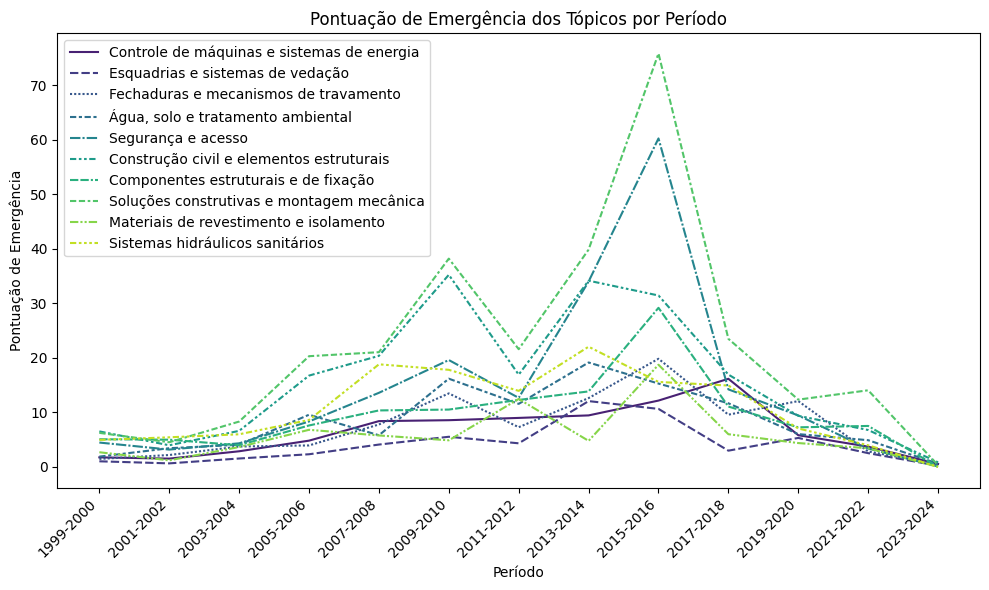

In [38]:
# Pega apenas as colunas que representam as probabilidades dos tópicos
probabilidades_topicos = patente_especifica[list(topic_names.values())]

# Cria o gráfico
plt.figure(figsize=(10, 6)) # Define o tamanho da figura
sns.lineplot(data=topic_emergence_scores, palette='viridis')

# Adiciona títulos e rótulos
plt.title(f'Pontuação de Emergência dos Tópicos por Período')
plt.xlabel('Período')
plt.ylabel('Pontuação de Emergência')
plt.xticks(rotation=45, ha='right') # Rotaciona os nomes dos tópicos para não sobrepor
plt.tight_layout() # Ajusta o layout para caber tudo

# Mostra o gráfico
plt.savefig('./graficos/emergencia_topicos_periodo.png', dpi=300)
plt.show()
plt.close()

In [41]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances, manhattan_distances
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Função otimizada (!!!pelo gemini não mexi nada dela!!!) para calcular similaridade entre patentes
def calculate_patent_similarity_optimized(df_topics, period_labels, topic_names, normalize=False, 
                                          similarity_method='cosine', similarity_threshold=0.95):
    """
    Calcula a similaridade entre patentes de períodos consecutivos de forma otimizada.
    
    Args:
        df_topics: DataFrame com dados das patentes e pontuações dos tópicos.
        period_labels: Lista com os rótulos dos períodos.
        topic_names: Dicionário com nomes dos tópicos.
        normalize: Boolean indicando se deve normalizar os dados.
        similarity_method: Método de similaridade ('cosine', 'euclidean', 'manhattan').
        similarity_threshold: Threshold mínimo para considerar similar.
    
    Returns:
        DataFrame: DataFrame original com colunas adicionais de similaridade.
    """
    
    # Cria uma cópia do DataFrame original para evitar modificar o original
    df_result = df_topics.copy()
    
    # Seleciona apenas as colunas dos tópicos para o cálculo
    topic_columns = list(topic_names.values())
    
    # Normaliza os dados se solicitado
    if normalize:
        scaler = StandardScaler()
        df_result[topic_columns] = scaler.fit_transform(df_result[topic_columns])
    
    # Inicializa novas colunas de forma eficiente
    # Em vez de listas, que podem ser lentas, inicializamos com um valor padrão.
    # Usaremos o tipo 'object' para poder armazenar listas de IDs e scores mais tarde.
    df_result['Patentes_Similares_IDs'] = pd.Series([[] for _ in range(len(df_result))], index=df_result.index).astype('object')
    df_result['Patentes_Similares_Scores'] = pd.Series([[] for _ in range(len(df_result))], index=df_result.index).astype('object')
    df_result['Max_Similarity_Score'] = 0.0
    df_result['Num_Patentes_Similares'] = 0
    df_result['Emergente'] = False
    
    def calculate_similarity_matrix(vectors1, vectors2, method):
        """Calcula a matriz de similaridade."""
        if method == 'cosine':
            return cosine_similarity(vectors1, vectors2)
        elif method == 'euclidean':
            distances = euclidean_distances(vectors1, vectors2)
            # Converte distância para similaridade (valores maiores são melhores)
            return 1 / (1 + distances)
        elif method == 'manhattan':
            distances = manhattan_distances(vectors1, vectors2)
            return 1 / (1 + distances)
        else:
            raise ValueError(f"Método não suportado: {method}")
    
    total_similarities_found = 0
    
    # Itera sobre pares de períodos consecutivos
    for i in range(len(period_labels) - 1):
        current_period = period_labels[i]
        next_period = period_labels[i + 1]
        
        print(f"Comparando período {current_period} com {next_period} usando {similarity_method}")
        
        # Filtra patentes dos períodos
        patents_current = df_result[df_result['Período'] == current_period]
        patents_next = df_result[df_result['Período'] == next_period]
        
        if patents_current.empty or patents_next.empty:
            print("Pulando comparação - um dos períodos está vazio.")
            continue
        
        # Extrai os vetores de tópicos
        vectors_current = patents_current[topic_columns].values
        vectors_next = patents_next[topic_columns].values
        
        # Calcula a matriz de similaridade completa
        similarity_matrix = calculate_similarity_matrix(vectors_current, vectors_next, similarity_method)
        
        # ===================================================================
        # INÍCIO DA SEÇÃO OTIMIZADA (VETORIZAÇÃO COM NUMPY)
        # ===================================================================
        
        # Passo 1: Encontrar a pontuação máxima de similaridade para cada patente do período atual.
        # O eixo 'axis=1' significa que operamos ao longo das colunas (para cada linha).
        max_scores = np.max(similarity_matrix, axis=1)
        
        # Passo 2: Contar quantas patentes no próximo período excedem o threshold para cada patente atual.
        num_similar = (similarity_matrix >= similarity_threshold).sum(axis=1)
        
        # Passo 3: Identificar quais patentes do período atual são emergentes.
        # Uma patente é emergente se tiver pelo menos uma similaridade acima do threshold.
        is_emergent = num_similar > 0
        
        # Passo 4: Atualizar o DataFrame de resultados de forma massiva, sem loops.
        # Usamos .loc para selecionar as linhas correspondentes às patentes do período atual.
        current_indices = patents_current.index
        df_result.loc[current_indices, 'Max_Similarity_Score'] = max_scores
        df_result.loc[current_indices, 'Num_Patentes_Similares'] = num_similar
        df_result.loc[current_indices, 'Emergente'] = is_emergent
        
        # Para os IDs e scores, ainda precisamos de um loop, pois a estrutura é mais complexa (lista de listas),
        # mas só iteramos sobre as patentes que SÃO emergentes, o que já é uma grande otimização.
        emergent_patents_indices = current_indices[is_emergent]
        
        for idx, matrix_row_idx in zip(emergent_patents_indices, np.where(is_emergent)[0]):
            similarities_row = similarity_matrix[matrix_row_idx]
            similar_mask = similarities_row >= similarity_threshold
            
            # Pega os índices e scores das patentes similares
            similar_patent_indices = patents_next.index[similar_mask]
            similar_ids = df_result.loc[similar_patent_indices, 'ID'].tolist()
            similar_scores = similarities_row[similar_mask].tolist()
            
            # Atribui as listas ao DataFrame
            df_result.at[idx, 'Patentes_Similares_IDs'] = similar_ids
            df_result.at[idx, 'Patentes_Similares_Scores'] = similar_scores

        # ===================================================================
        # FIM DA SEÇÃO OTIMIZADA
        # ===================================================================

        period_similarities = num_similar.sum()
        total_similarities_found += period_similarities
        emergent_patents_count = is_emergent.sum()
        
        print(f"Período {current_period}: {emergent_patents_count} patentes emergentes, {period_similarities} similaridades encontradas")
    
    print(f"\nTotal de similaridades encontradas: {total_similarities_found}")
    print(f"Total de patentes emergentes: {df_result['Emergente'].sum()}")
    
    return df_result

def calculate_patent_similarity(df_topics, period_labels, topic_names, normalize=False, 
                              similarity_method='cosine', similarity_threshold=0.95):
    """
    Calcula a similaridade entre patentes de períodos consecutivos usando diferentes métodos.
    
    Args:
        df_topics: DataFrame com dados das patentes e pontuações dos tópicos
        period_labels: Lista com os rótulos dos períodos
        topic_names: Dicionário com nomes dos tópicos
        normalize: Boolean indicando se deve normalizar os dados
        similarity_method: Método de similaridade ('cosine', 'euclidean', 'manhattan')
        similarity_threshold: Threshold mínimo para considerar similar
    
    Returns:
        DataFrame: DataFrame original com colunas adicionais de similaridade
    """
    
    # Cria uma cópia do DataFrame original
    df_result = df_topics.copy()
    
    # Seleciona apenas as colunas dos tópicos para cálculo de similaridade
    topic_columns = list(topic_names.values())
    
    # Normaliza os dados se solicitado
    if normalize:
        scaler = StandardScaler()
        df_result[topic_columns] = scaler.fit_transform(df_result[topic_columns])
    
    # Inicializa novas colunas
    df_result['Patentes_Similares_IDs'] = [[] for _ in range(len(df_result))]
    df_result['Patentes_Similares_Scores'] = [[] for _ in range(len(df_result))]
    df_result['Max_Similarity_Score'] = 0.0
    df_result['Num_Patentes_Similares'] = 0
    df_result['Emergente'] = False
    
    def calculate_similarity_matrix(vectors1, vectors2, method):
        """Calcula matriz de similaridade usando diferentes métodos"""
        if method == 'cosine':
            return cosine_similarity(vectors1, vectors2)
        elif method == 'euclidean':
            distances = euclidean_distances(vectors1, vectors2)
            return np.exp(-distances)  # Converte distância em similaridade
        elif method == 'manhattan':
            distances = manhattan_distances(vectors1, vectors2)
            return np.exp(-distances)  # Converte distância em similaridade
        else:
            raise ValueError(f"Método não suportado: {method}")
    
    # Itera sobre pares de períodos consecutivos
    total_similarities_found = 0
    
    for i in range(len(period_labels) - 1):
        current_period = period_labels[i]
        next_period = period_labels[i + 1]
        
        print(f"Comparando período {current_period} com {next_period} usando {similarity_method}")
        
        # Filtra patentes dos períodos atual e próximo
        patents_current = df_result[df_result['Período'] == current_period]
        patents_next = df_result[df_result['Período'] == next_period]
        
        if len(patents_current) == 0 or len(patents_next) == 0:
            print(f"Pulando comparação - período vazio")
            continue
        
        vectors_current = patents_current[topic_columns].values
        vectors_next = patents_next[topic_columns].values
        
        # Calcula matriz de similaridade
        # matriz onde cada linha é uma patente do período atual e cada coluna do próximo período
        similarity_matrix = calculate_similarity_matrix(vectors_current, vectors_next, similarity_method)
        period_similarities = 0
        
        # Para cada patente do período atual, encontra similares no próximo período
        for idx_current, patent_current_idx in enumerate(patents_current.index):
            similarities_row = similarity_matrix[idx_current]
            
            # Encontra todas as patentes similares acima do threshold
            similar_indices = np.where(similarities_row >= similarity_threshold)[0]
            
            if len(similar_indices) > 0:
                similar_patent_indices = patents_next.index[similar_indices]
                similar_ids = [df_result.loc[idx, 'ID'] for idx in similar_patent_indices]
                similar_scores = similarities_row[similar_indices].tolist()
                
                df_result.at[patent_current_idx, 'Patentes_Similares_IDs'] = similar_ids
                df_result.at[patent_current_idx, 'Patentes_Similares_Scores'] = similar_scores
                df_result.at[patent_current_idx, 'Max_Similarity_Score'] = max(similar_scores)
                df_result.at[patent_current_idx, 'Num_Patentes_Similares'] = len(similar_ids)
                df_result.at[patent_current_idx, 'Emergente'] = True
                
                period_similarities += len(similar_indices)
                total_similarities_found += len(similar_indices)
        
        emergent_patents = patents_current[df_result.loc[patents_current.index, 'Emergente']].shape[0]
        print(f"Período {current_period}: {emergent_patents} patentes emergentes, {period_similarities} similaridades encontradas")
    
    print(f"\nTotal de similaridades encontradas: {total_similarities_found}")
    print(f"Total de patentes emergentes: {df_result['Emergente'].sum()}")
    
    return df_result

# Configurações para diferentes métodos
similarity_methods = ['cosine', 'euclidean', 'manhattan']
# similarity_thresholds = [0.95, 0.90, 0.85]
similarity_thresholds = [0.95]

print("=== TESTANDO DIFERENTES MÉTODOS DE SIMILARIDADE ===")

results = {}

# Testa cada método com os dados (Tipo um grid search)
for method in similarity_methods:
    for threshold in similarity_thresholds:
        for normalize in [False, True]:
            normalize_label = "normalizado" if normalize else "normal"
            key = f"{method}_{normalize_label}_{threshold}"
            
            print(f"\n=== {method.upper()} - Dados {normalize_label.upper()} - Threshold {threshold} ===")
            
            try:
                df_result = calculate_patent_similarity_optimized(
                    df_topics, 
                    period_labels, 
                    topic_names, 
                    normalize=normalize,
                    similarity_method=method,
                    similarity_threshold=threshold
                )
                
                results[key] = df_result
                
                # Estatísticas resumidas
                emergent_count = df_result['Emergente'].sum()
                total_similarities = df_result['Num_Patentes_Similares'].sum()
                avg_similarities_per_emergent = total_similarities / emergent_count if emergent_count > 0 else 0
                
                print(f"Patentes emergentes: {emergent_count}")
                print(f"Total de similaridades: {total_similarities}")
                print(f"Média de similaridades por patente emergente: {avg_similarities_per_emergent:.2f}")
                
            except Exception as e:
                print(f"Erro com método {method}: {e}")
                results[key] = None

=== TESTANDO DIFERENTES MÉTODOS DE SIMILARIDADE ===

=== COSINE - Dados NORMAL - Threshold 0.95 ===
Comparando período 1999-2000 com 2001-2002 usando cosine
Período 1999-2000: 1279 patentes emergentes, 55201 similaridades encontradas
Comparando período 2001-2002 com 2003-2004 usando cosine
Período 2001-2002: 1823 patentes emergentes, 67044 similaridades encontradas
Comparando período 2003-2004 com 2005-2006 usando cosine
Período 2003-2004: 1569 patentes emergentes, 57619 similaridades encontradas
Comparando período 2005-2006 com 2007-2008 usando cosine
Período 2005-2006: 1555 patentes emergentes, 47453 similaridades encontradas
Comparando período 2007-2008 com 2009-2010 usando cosine
Período 2007-2008: 1256 patentes emergentes, 35570 similaridades encontradas
Comparando período 2009-2010 com 2011-2012 usando cosine
Período 2009-2010: 1106 patentes emergentes, 31405 similaridades encontradas
Comparando período 2011-2012 com 2013-2014 usando cosine
Período 2011-2012: 1063 patentes emerge

In [42]:
# Comparação dos resultados
print("\n=== COMPARAÇÃO DOS MÉTODOS ===")
print(f"{'Método':<15} {'Normalizado':<12} {'Threshold':<10} {'Emergentes':<12} {'Similaridades':<14} {'Média/Patente':<14}")
print("-" * 90)

for key, df_result in results.items():
    if df_result is not None:
        method, normalize_label, threshold = key.split('_')
        emergent_count = df_result['Emergente'].sum()
        total_similarities = df_result['Num_Patentes_Similares'].sum()
        avg_per_patent = total_similarities / emergent_count if emergent_count > 0 else 0
        
        print(f"{method:<15} {normalize_label:<12} {threshold:<10} {emergent_count:<12} {total_similarities:<14} {avg_per_patent:<14.2f}")

df_cosine_normalizado_095 = results['cosine_normalizado_0.95']
df_euclidean_normalizado_095 = results['euclidean_normalizado_0.95']
df_manhattan_normalizado_095 = results['manhattan_normalizado_0.95']
df_cosine_normal_095 = results['cosine_normal_0.95']
df_euclidean_normal_095 = results['euclidean_normal_0.95']
df_manhattan_normal_095 = results['manhattan_normal_0.95']




=== COMPARAÇÃO DOS MÉTODOS ===
Método          Normalizado  Threshold  Emergentes   Similaridades  Média/Patente 
------------------------------------------------------------------------------------------
cosine          normal       0.95       22030        1009037        45.80         
cosine          normalizado  0.95       20733        659267         31.80         
euclidean       normal       0.95       6978         35456          5.08          
euclidean       normalizado  0.95       2271         12692          5.59          
manhattan       normal       0.95       4639         22777          4.91          
manhattan       normalizado  0.95       1873         11796          6.30          
